In [54]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [55]:
df= pd.read_csv("smartcart_customers.csv")

In [56]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


In [57]:
df.shape
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Complain                0
Response                0
dtype: int64

DATA PREPROCESSING

1. Handling Missing Values

In [58]:
df["Income"] = df["Income"].fillna(df["Income"].median())

FEATURE ENGINEERING

In [59]:
# age
df["age"] = 2026 - df["Year_Birth"]

In [60]:
# customer join date
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"], dayfirst=True)
refrence_date = df["Dt_Customer"].max()
df["customer_tenure_days"] = (refrence_date - df["Dt_Customer"]).dt.days

In [61]:
# Ṭotal spending
df["total_spending"] = df["MntWines"] + df["MntFruits"] + df["MntMeatProducts"] + df["MntFishProducts"] + df["MntSweetProducts"] + df["MntGoldProds"]

In [62]:
# total children
df["total_children"] = df["Kidhome"] + df["Teenhome"]

In [63]:
# education 
df["Education"]= df["Education"].replace({
    "Basic":"undergraduate" , "2n Cycle":"undergraduate",
    "Master" : "postgraduate" , "PhD":"postgraduate",
    "Graduation": "graduate"
})

In [64]:
df["Education"].value_counts()

Education
graduate         1127
postgraduate      856
undergraduate     257
Name: count, dtype: int64

In [65]:
# marital status
df["living with"] = df["Marital_Status"].replace({
    "Married" : "partner" , "Together" : "partner",
    "Single" : "alone" , "Divorced":"alone" , "Widow": "alone", "Alone":"alone","Absurd":"alone", "YOLO":"alone"
})

In [66]:
df["living with"].value_counts()

living with
partner    1444
alone       796
Name: count, dtype: int64

In [67]:
cols = ["ID" , "Year_Birth", "Marital_Status" , "Kidhome", "Teenhome", "Dt_Customer", "MntWines","MntFruits","MntMeatProducts", "MntFishProducts", "MntSweetProducts","MntGoldProds"]

df_cleaned = df.drop(columns=cols)

In [68]:
df_cleaned.head()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,age,customer_tenure_days,total_spending,total_children,living with
0,graduate,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,alone
1,graduate,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,alone
2,graduate,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,partner
3,graduate,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,partner
4,postgraduate,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,partner


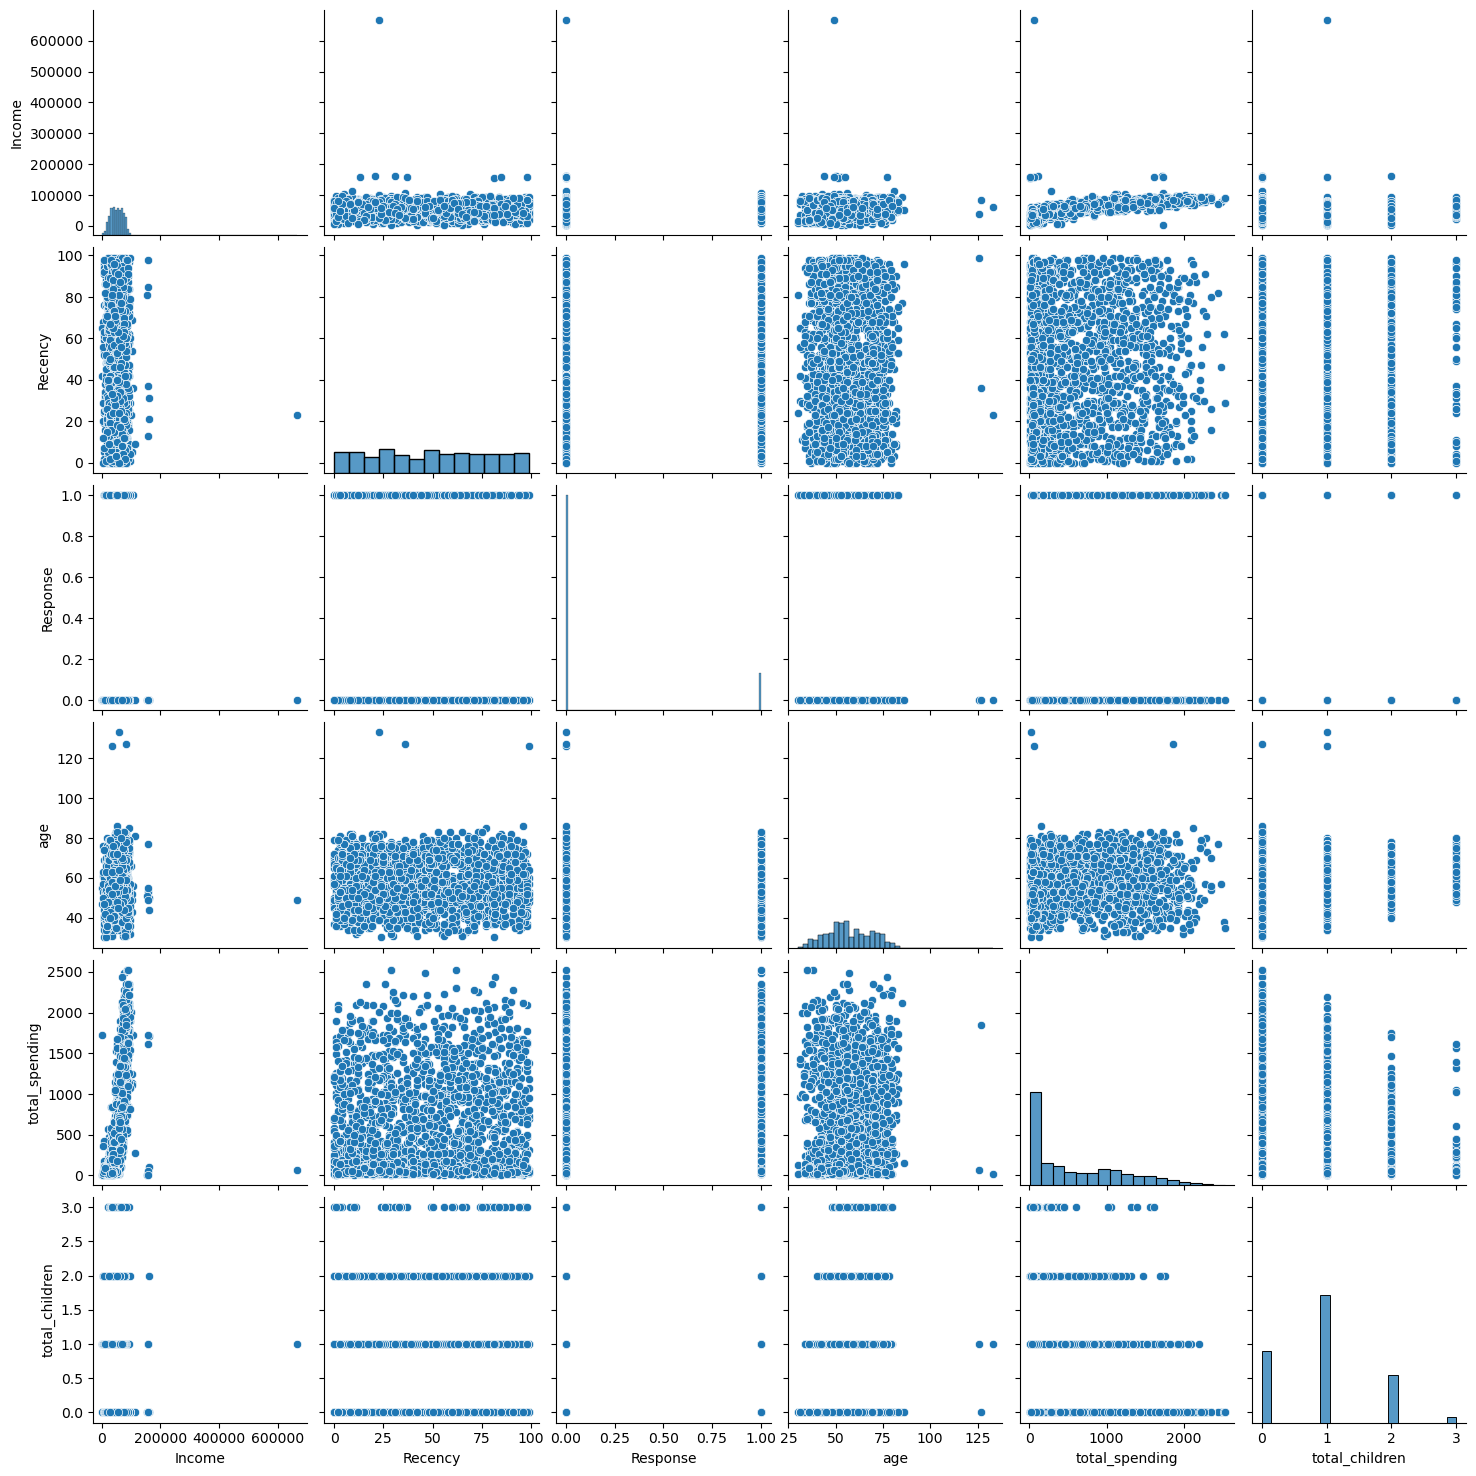

In [69]:
cols = ["Income", "Recency", "Response", "age", "total_spending", "total_children"]

# relative plots of some features- pair plots
sns.pairplot(df_cleaned[cols])

In [70]:
# REMOVE OUTLIERS
print("data size with outliers:" , len(df_cleaned))

df_cleaned = df_cleaned[(df_cleaned["age"]<90)]
df_cleaned = df_cleaned[(df_cleaned["Income"]<600000)]

print("data size without outliers: ", len(df_cleaned))

data size with outliers: 2240
data size without outliers:  2236


In [71]:
corr = df_cleaned.corr(numeric_only=True)

<Axes: >

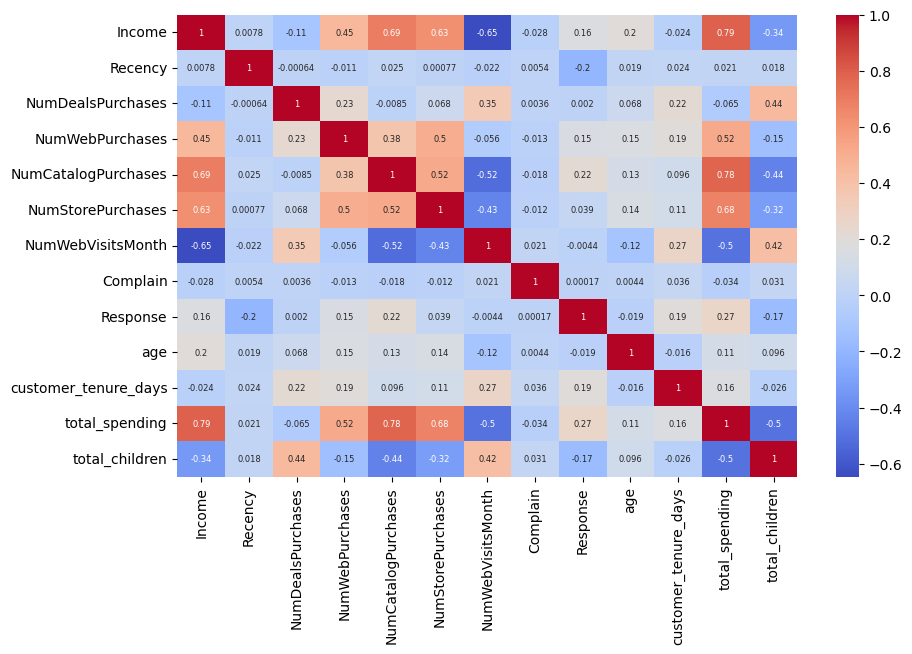

In [72]:
plt.figure(figsize= (10,6))

sns.heatmap(
    corr,
    annot=True,
    annot_kws={"size": 6},
    cmap = "coolwarm"
)

ENCODING

In [73]:
from sklearn.preprocessing import OneHotEncoder

In [74]:
ohe = OneHotEncoder()

cat_cols = ["Education", "living with"]

enc_cols= ohe.fit_transform(df_cleaned[cat_cols])

In [75]:
enc_df = pd.DataFrame(enc_cols.toarray(), columns=ohe.get_feature_names_out(cat_cols), index=df_cleaned.index)

In [76]:
enc_df.head()

,Education_graduate,Education_postgraduate,Education_undergraduate,living with_alone,living with_partner
0,1.0,0.0,0.0,1.0,0.0
1,1.0,0.0,0.0,1.0,0.0
2,1.0,0.0,0.0,0.0,1.0
3,1.0,0.0,0.0,0.0,1.0
4,0.0,1.0,0.0,0.0,1.0


In [77]:
df_encoded = pd.concat([df_cleaned.drop(columns=cat_cols), enc_df],axis=1)

In [78]:
df_encoded.shape

(2236, 18)

In [79]:
x=df_encoded

SCALING

In [80]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_scaled = scaler.fit_transform(x)

VISUALIZATION

In [81]:
from sklearn.decomposition import PCA

In [82]:
pca = PCA(n_components = 3)

x_pca = pca.fit_transform(x_scaled)

In [83]:
pca.explained_variance_ratio_

array([0.23163158, 0.11385454, 0.10405815])

In [84]:
pca.explained_variance_ratio_

array([0.23163158, 0.11385454, 0.10405815])

Text(0.5, 0.92, '3d projection')

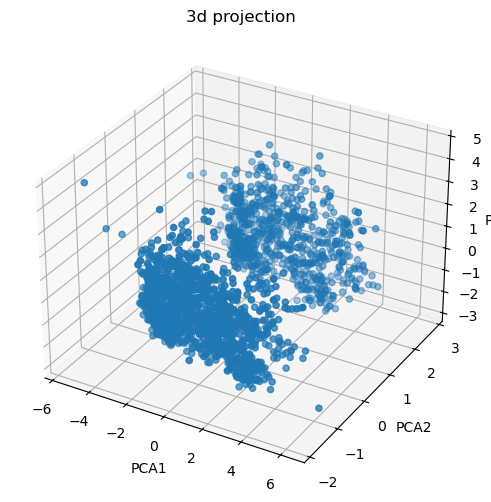

In [85]:
# plot
fig = plt.figure(figsize = (8,6))

ax = fig.add_subplot(111, projection = "3d")

ax.scatter(x_pca[:,0] , x_pca[:, 1], x_pca[:,2])

ax.set_xlabel("PCA1")
ax.set_ylabel("PCA2")
ax.set_zlabel("PCA3")
ax.set_title("3d projection")

ANALYZE K VALUE

1. Elbow Method

In [87]:
from sklearn.cluster import KMeans
from kneed import KneeLocator

wcss = []
for k in range(1,11):
    kmeans = KMeans(n_clusters = k , random_state=42)
    kmeans.fit_predict(x_pca)
    wcss.append(kmeans.inertia_)

In [88]:
knee = KneeLocator(range(1, 11), wcss, curve="convex", direction="decreasing")
optimal_k = knee.elbow

In [89]:
print("best k value: " , optimal_k)

best k value:  4


Text(0, 0.5, 'WCSS')

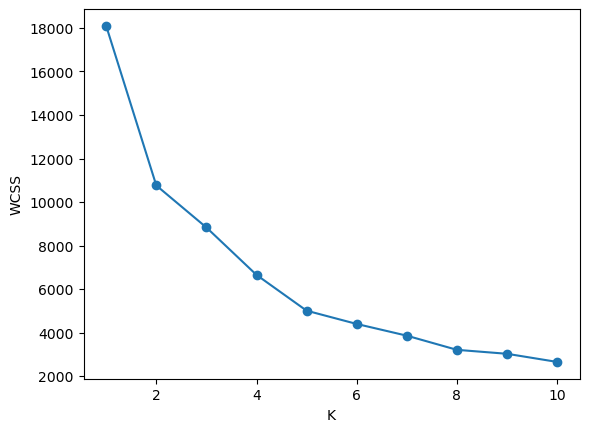

In [90]:
# plot
plt.plot(range(1,11), wcss, marker='o')
plt.xlabel("K")
plt.ylabel("WCSS")

2. SILHOUETTE SCORE

Text(0, 0.5, 'silhouette score')

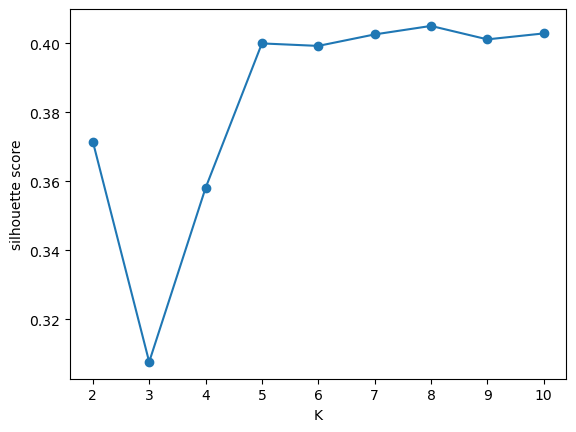

In [95]:
from sklearn.metrics import silhouette_score

scores = []

for k in range(2,11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(x_pca)
    score = silhouette_score(x_pca, labels)
    scores.append(score)

# plot
plt.plot(range(2,11), scores, marker = 'o')
plt.xlabel("K")
plt.ylabel("silhouette score")

Text(0, 0.5, 'SS')

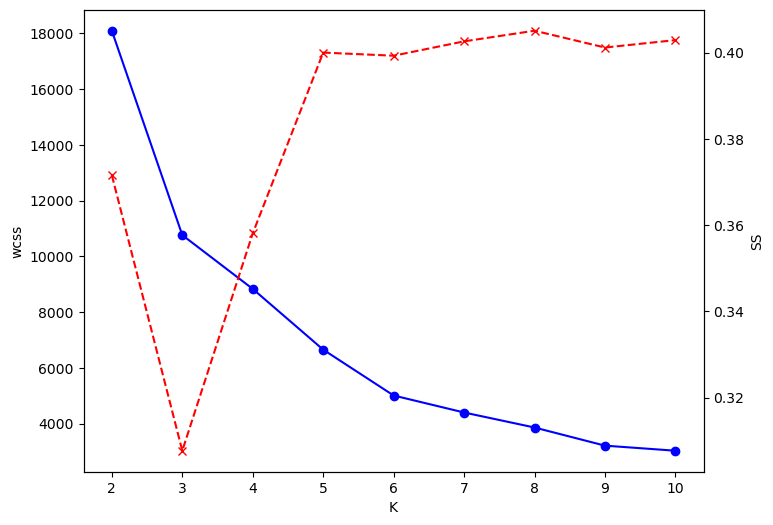

In [101]:
# COMBINED PLOT

k_range = range(2,11)

fig, ax1 = plt.subplots(figsize=(8,6))
ax1.plot(k_range, wcss[:len(k_range)], marker='o', color= "blue")
ax1.set_xlabel("K")
ax1.set_ylabel("wcss")

ax2 = ax1.twinx()
ax2.plot(k_range, scores[:len(k_range)], marker="x", color="red",linestyle= "--")
ax2.set_ylabel("SS")

CLUSTERING

In [102]:
kmeans = KMeans(n_clusters= 4, random_state=42)
labels_kmeans = kmeans.fit_predict(x_pca)

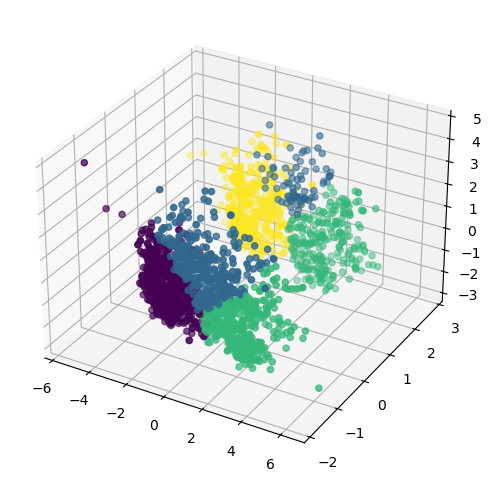

In [104]:
fig = plt.figure(figsize = (8,6))

ax = fig.add_subplot(111, projection = "3d")

ax.scatter(x_pca[:,0] , x_pca[:, 1], x_pca[:,2], c=labels_kmeans)

In [105]:
# AGGLOMERATIVE CLUSTERING

from sklearn.cluster import AgglomerativeClustering

In [106]:
agg_clf= AgglomerativeClustering(n_clusters=4, linkage= "ward")
labels_agg = agg_clf.fit_predict(x_pca)

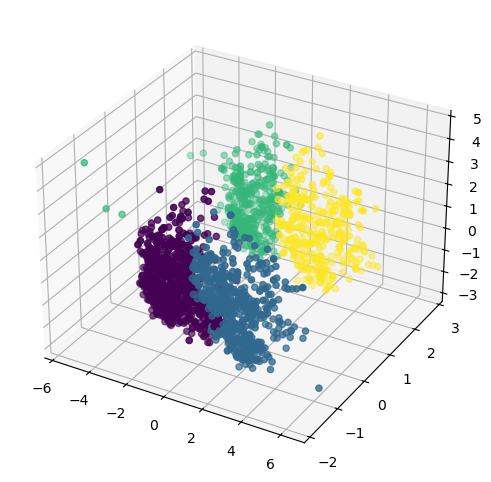

In [107]:
fig = plt.figure(figsize = (8,6))

ax = fig.add_subplot(111, projection = "3d")

ax.scatter(x_pca[:,0] , x_pca[:, 1], x_pca[:,2], c=labels_agg)


CHARACTERIZATION OF CLUSTERS

In [121]:
x["cluster"]=labels_agg

<Axes: xlabel='cluster', ylabel='count'>

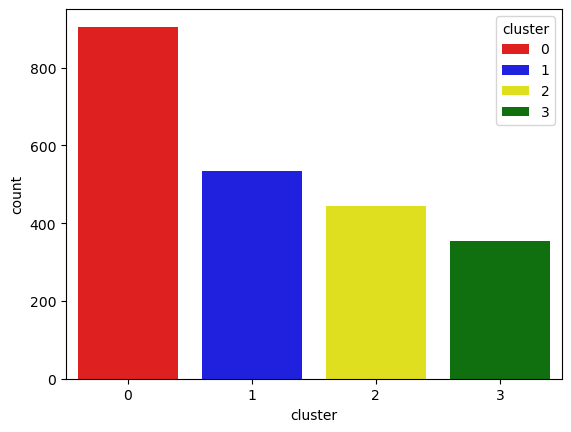

In [126]:
pal = ["red", "blue", "yellow", "green"]

sns.countplot(x=x["cluster"], palette=pal, hue=x["cluster"])

<Axes: xlabel='total_spending', ylabel='Income'>

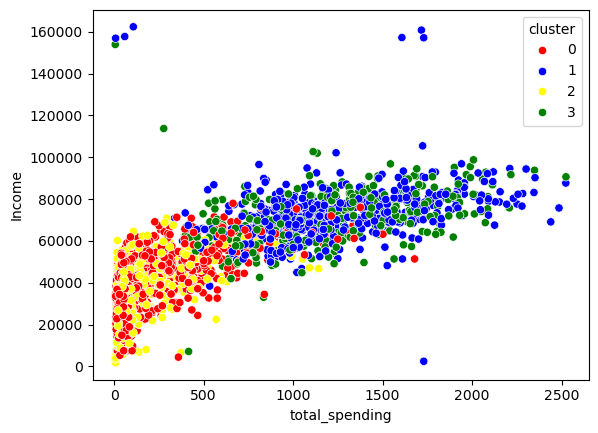

In [129]:
x.drop("labels", axis=1)
x["cluster"]=labels_agg

sns.scatterplot(x=x["total_spending"], y=df_cleaned["Income"], hue=x["cluster"],palette=pal)

In [113]:
df_cleaned.head()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,age,customer_tenure_days,total_spending,total_children,living with,labels
0,graduate,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,alone,3
1,graduate,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,alone,2
2,graduate,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,partner,1
3,graduate,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,partner,0
4,postgraduate,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,partner,0


<Axes: xlabel='NumCatalogPurchases', ylabel='Income'>

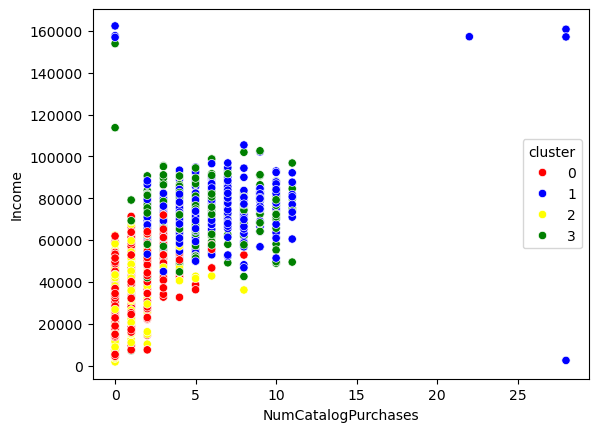

In [117]:
sns.scatterplot(x=df_cleaned["NumCatalogPurchases"], y=df_cleaned["Income"], hue=df_cleaned["cluster"],palette=pal)

<Axes: xlabel='NumStorePurchases', ylabel='Income'>

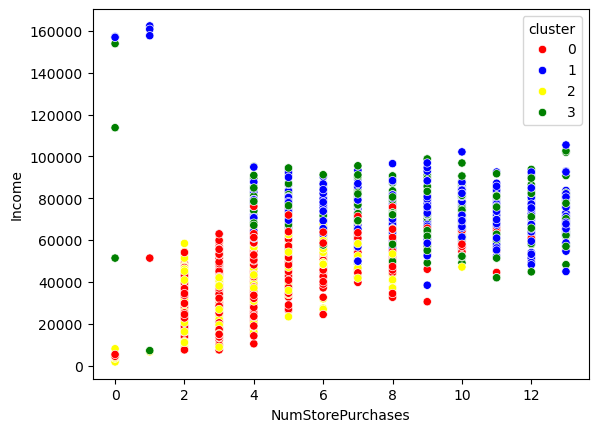

In [118]:
sns.scatterplot(x=df_cleaned["NumStorePurchases"], y=df_cleaned["Income"], hue=df_cleaned["cluster"],palette=pal)

In [130]:
# cluster summary
cluster_summary = x.groupby("cluster").mean()
print(cluster_summary)

               Income    Recency  NumDealsPurchases  NumWebPurchases  \
cluster                                                                
0        39680.580110  48.914917           2.594475         3.153591   
1        72808.445693  49.202247           1.958801         5.687266   
2        36960.143018  48.319820           2.594595         2.713964   
3        70722.681303  50.504249           1.855524         5.790368   

         NumCatalogPurchases  NumStorePurchases  NumWebVisitsMonth  Complain  \
cluster                                                                        
0                   0.969061           4.143646           6.307182  0.011050   
1                   5.498127           8.659176           3.580524  0.005618   
2                   0.837838           3.623874           6.659910  0.011261   
3                   5.014164           8.430595           3.728045  0.005666   

         Response        age  customer_tenure_days  total_spending  \
cluster         